# 02 Data Quality

This notebook sets up Great Expectations, defines expectation suites, validates raw and processed data, and inspects the merged match-level dataframe.

In [1]:
from pathlib import Path
import json

import great_expectations as gx
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
INTERIM_DIR = DATA_DIR / 'interim'
PROCESSED_DIR = DATA_DIR / 'processed'

In [2]:
matches_df = pd.read_csv(RAW_DIR / 'matches.csv')
participants_df = pd.read_csv(RAW_DIR / 'participants.csv')
teamstats_df = pd.read_csv(RAW_DIR / 'teamstats.csv')
stats1_df = pd.read_csv(RAW_DIR / 'stats1.csv')
stats2_df = pd.read_csv(RAW_DIR / 'stats2.csv')
stats2_df = stats2_df[stats1_df.columns]
stats_df = pd.concat([stats1_df, stats2_df], axis=0, ignore_index=True)

merged_df = pd.read_csv(INTERIM_DIR / 'match_level_dataset.csv.gz')
processed_train_df = pd.read_csv(PROCESSED_DIR / 'train.csv.gz')

{
    'matches': matches_df.shape,
    'stats': stats_df.shape,
    'merged': merged_df.shape,
    'processed_train': processed_train_df.shape,
}

/tmp/ipykernel_11857/3723790473.py:5: DtypeWarning: Columns (0: wardsbought) have mixed types. Specify dtype option on import or set low_memory=False.
  stats2_df = pd.read_csv(RAW_DIR / 'stats2.csv')


{'matches': (184069, 8),
 'stats': (1834517, 56),
 'merged': (1786565, 83),
 'processed_train': (1250640, 82)}

## Merged Dataframe Preview and Visualization

In [3]:
display(merged_df.head(10))
display(merged_df[['matchid', 'teamid', 'win', 'kills', 'deaths', 'assists', 'goldearned']].describe(include='all'))

,id,matchid,player,championid,ss1,ss2,role,position,win,item1,...,firsttower,firstinhib,firstbaron,firstdragon,firstharry,towerkills,inhibkills_team,baronkills,dragonkills,harrykills
0,9,10,1,19,4,11,NONE,JUNGLE,0,3748,...,1,0,0,0,0,5,0,0,0,0
1,10,10,2,267,3,4,DUO_SUPPORT,BOT,0,2301,...,1,0,0,0,0,5,0,0,0,0
2,11,10,3,119,7,4,DUO_CARRY,BOT,0,1055,...,1,0,0,0,0,5,0,0,0,0
3,12,10,4,114,12,4,SOLO,TOP,0,1029,...,1,0,0,0,0,5,0,0,0,0
4,13,10,5,112,4,3,SOLO,MID,0,3020,...,1,0,0,0,0,5,0,0,0,0
5,14,10,6,72,11,4,NONE,JUNGLE,1,1400,...,0,1,1,1,1,10,3,1,3,1
6,15,10,7,3,4,12,SOLO,TOP,1,3025,...,0,1,1,1,1,10,3,1,3,1
7,16,10,8,103,14,4,SOLO,MID,1,3135,...,0,1,1,1,1,10,3,1,3,1
8,17,10,9,222,7,4,DUO_CARRY,BOT,1,3046,...,0,1,1,1,1,10,3,1,3,1
9,18,10,10,161,14,4,DUO_SUPPORT,BOT,1,1058,...,0,1,1,1,1,10,3,1,3,1


,matchid,teamid,win,kills,deaths,assists,goldearned
count,1.786565e+06,1.786565e+06,1786565.0,1.786565e+06,1.786565e+06,1.786565e+06,1.786565e+06
mean,9.488331e+04,1.498290e+02,0.5,5.941575e+00,5.965226e+00,8.539301e+00,1.169804e+04
std,5.361883e+04,4.999972e+01,0.5,4.568382e+00,3.169488e+00,5.844108e+00,3.667078e+03
min,1.000000e+01,1.000000e+02,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.070000e+03
25%,4.862800e+04,1.000000e+02,0.0,2.000000e+00,4.000000e+00,4.000000e+00,9.082000e+03
50%,9.471600e+04,1.000000e+02,0.0,5.000000e+00,6.000000e+00,7.000000e+00,1.147300e+04
75%,1.413950e+05,2.000000e+02,1.0,9.000000e+00,8.000000e+00,1.200000e+01,1.401900e+04
max,1.875880e+05,2.000000e+02,1.0,4.500000e+01,3.800000e+01,5.700000e+01,4.098200e+04


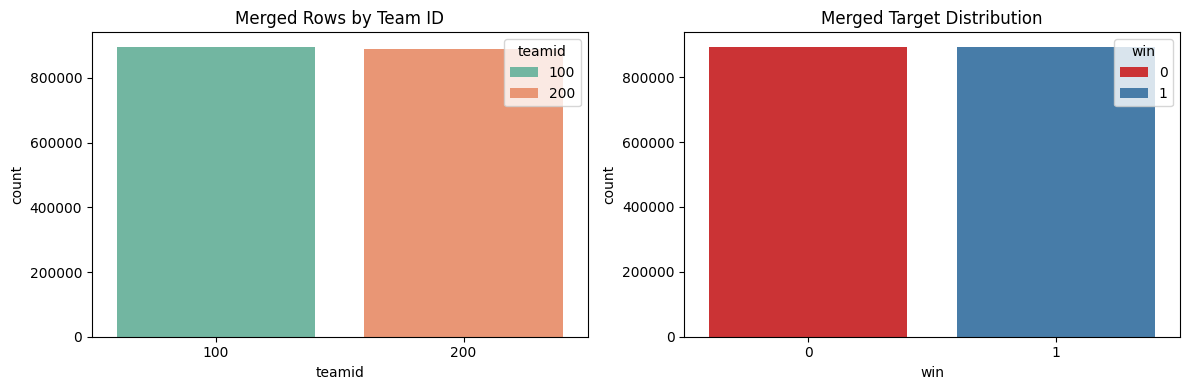

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=merged_df, x='teamid', hue='teamid', palette='Set2', ax=axes[0])
axes[0].set_title('Merged Rows by Team ID')
axes[0].set_xlabel('teamid')

sns.countplot(data=merged_df, x='win', hue='win', palette='Set1', ax=axes[1])
axes[1].set_title('Merged Target Distribution')
axes[1].set_xlabel('win')

plt.tight_layout()
plt.show()

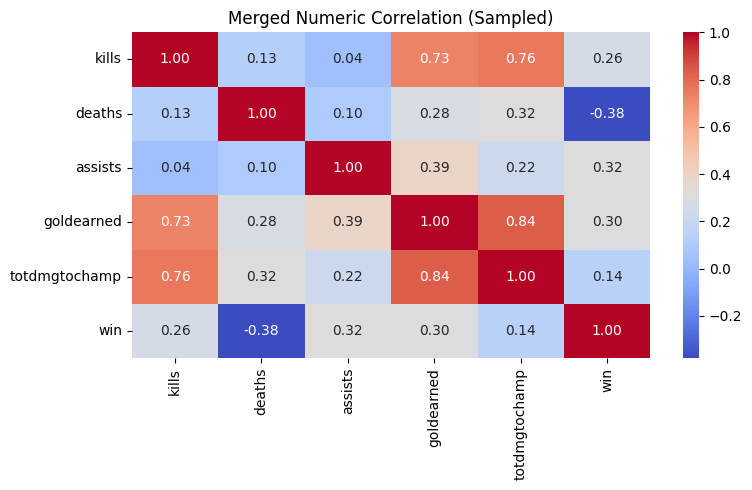

In [5]:
sample = merged_df[['kills', 'deaths', 'assists', 'goldearned', 'totdmgtochamp', 'win']].sample(50000, random_state=42)
corr = sample.corr(numeric_only=True)

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Merged Numeric Correlation (Sampled)')
plt.tight_layout()
plt.show()

## Great Expectations Setup

In [6]:
context = gx.get_context(mode='file', project_root_dir=str(PROJECT_ROOT / 'great_expectations'))
data_source = context.data_sources.add_or_update_pandas(name='lol_match_oracle')

def ensure_asset(name: str):
    names = data_source.get_asset_names()
    return data_source.get_asset(name) if name in names else data_source.add_dataframe_asset(name)

def ensure_batch_definition(asset, name: str):
    try:
        return asset.get_batch_definition(name)
    except Exception:
        return asset.add_batch_definition_whole_dataframe(name)

raw_matches_asset = ensure_asset('raw_matches')
raw_stats_asset = ensure_asset('raw_stats')
processed_asset = ensure_asset('processed_train')

raw_matches_bd = ensure_batch_definition(raw_matches_asset, 'raw_matches_full')
raw_stats_bd = ensure_batch_definition(raw_stats_asset, 'raw_stats_full')
processed_bd = ensure_batch_definition(processed_asset, 'processed_train_full')

## Raw Matches Expectation Suite

In [7]:
raw_matches_suite = context.suites.add_or_update(gx.ExpectationSuite(name='raw_matches_suite'))
raw_matches_validator = context.get_validator(
    batch_request=raw_matches_bd.build_batch_request(batch_parameters={'dataframe': matches_df}),
    expectation_suite=raw_matches_suite,
)
raw_matches_validator.default_expectation_args.pop('result_format', None)

raw_matches_validator.expect_table_columns_to_match_set([
    'id', 'gameid', 'platformid', 'queueid', 'seasonid', 'duration', 'creation', 'version'
])
raw_matches_validator.expect_column_values_to_not_be_null('id')
raw_matches_validator.expect_column_values_to_be_unique('id')
raw_matches_validator.expect_column_values_to_not_be_null('gameid')
raw_matches_validator.expect_column_values_to_be_between('duration', min_value=300, max_value=7200, mostly=0.97)

season_ids = pd.to_numeric(matches_df['seasonid'], errors='coerce').dropna().astype(int).unique().tolist()
raw_matches_validator.expect_column_values_to_be_in_set('seasonid', season_ids)

context.suites.add_or_update(raw_matches_validator.expectation_suite)
raw_matches_validator.get_expectation_suite()

Calculating Metrics: 100%|██████████| 8/8 [00:00<00:00, 823.52it/s] 


{
  "name": "raw_matches_suite",
  "id": "44b26a94-a051-457a-b89f-a8875c206ee4",
  "expectations": [
    {
      "type": "expect_table_columns_to_match_set",
      "kwargs": {
        "column_set": [
          "id",
          "gameid",
          "platformid",
          "queueid",
          "seasonid",
          "duration",
          "creation",
          "version"
        ]
      },
      "meta": {},
      "id": "5dcd81fb-e3f2-4f03-a281-57ccf473d3c7",
      "severity": "critical"
    },
    {
      "type": "expect_column_values_to_not_be_null",
      "kwargs": {
        "column": "id"
      },
      "meta": {},
      "id": "ddcbacba-fb20-4404-8651-3bff066c7304",
      "severity": "critical"
    },
    {
      "type": "expect_column_values_to_be_unique",
      "kwargs": {
        "column": "id"
      },
      "meta": {},
      "id": "2c23ac03-9b88-48d4-9311-896c00d1c7c1",
      "severity": "critical"
    },
    {
      "type": "expect_column_values_to_not_be_null",
      "kwargs": {
   

## Raw Stats Expectation Suite

In [8]:
raw_stats_suite = context.suites.add_or_update(gx.ExpectationSuite(name='raw_stats_suite'))
raw_stats_validator = context.get_validator(
    batch_request=raw_stats_bd.build_batch_request(batch_parameters={'dataframe': stats_df}),
    expectation_suite=raw_stats_suite,
)
raw_stats_validator.default_expectation_args.pop('result_format', None)

for col in ['id', 'win', 'kills', 'deaths', 'assists', 'goldearned', 'totdmgtochamp']:
    raw_stats_validator.expect_column_to_exist(col)

raw_stats_validator.expect_column_values_to_not_be_null('id')
raw_stats_validator.expect_column_values_to_be_unique('id')
raw_stats_validator.expect_column_values_to_be_in_set('win', [0, 1])

for col in ['kills', 'deaths', 'assists', 'goldearned', 'totdmgtochamp']:
    raw_stats_validator.expect_column_values_to_be_between(col, min_value=0)

context.suites.add_or_update(raw_stats_validator.expectation_suite)
raw_stats_validator.get_expectation_suite()

Calculating Metrics: 100%|██████████| 8/8 [00:00<00:00, 856.50it/s] 


{
  "name": "raw_stats_suite",
  "id": "54937dcd-e862-4c59-a860-e273a05112fb",
  "expectations": [
    {
      "type": "expect_column_to_exist",
      "kwargs": {
        "column": "totdmgtochamp"
      },
      "meta": {},
      "id": "10ed9332-6452-4e50-8e15-c7ebf8848e57",
      "severity": "critical"
    },
    {
      "type": "expect_column_values_to_not_be_null",
      "kwargs": {
        "column": "id"
      },
      "meta": {},
      "id": "c28cf583-9e9b-44d3-9370-357b5ffc254c",
      "severity": "critical"
    },
    {
      "type": "expect_column_values_to_be_unique",
      "kwargs": {
        "column": "id"
      },
      "meta": {},
      "id": "8a310731-4557-457a-94df-5eaa323eb5ed",
      "severity": "critical"
    },
    {
      "type": "expect_column_values_to_be_in_set",
      "kwargs": {
        "column": "win",
        "value_set": [
          0,
          1
        ]
      },
      "meta": {},
      "id": "8183c4b7-7054-429b-96c3-8248550a479f",
      "severity": "crit

## Processed Features Expectation Suite

In [9]:
processed_suite = context.suites.add_or_update(gx.ExpectationSuite(name='processed_features_suite'))
processed_validator = context.get_validator(
    batch_request=processed_bd.build_batch_request(batch_parameters={'dataframe': processed_train_df}),
    expectation_suite=processed_suite,
)
processed_validator.default_expectation_args.pop('result_format', None)

processed_validator.expect_column_to_exist('win')
processed_validator.expect_column_values_to_be_in_set('win', [0, 1])

for col in processed_train_df.columns:
    processed_validator.expect_column_values_to_not_be_null(col)

leakage_cols = ['winner', 'result', 'bluewins']
present_leakage = [c for c in leakage_cols if c in processed_train_df.columns]
if present_leakage:
    raise ValueError(f'Leakage columns found: {present_leakage}')

context.suites.add_or_update(processed_validator.expectation_suite)
processed_validator.get_expectation_suite()

Calculating Metrics: 100%|██████████| 6/6 [00:00<00:00, 1114.91it/s]


{
  "name": "processed_features_suite",
  "id": "be1728b0-125a-4f96-b2b4-f3dc92b0549f",
  "expectations": [
    {
      "type": "expect_column_to_exist",
      "kwargs": {
        "column": "win"
      },
      "meta": {},
      "id": "cbbf1f29-3b80-4822-b608-4aed9458f534",
      "severity": "critical"
    },
    {
      "type": "expect_column_values_to_be_in_set",
      "kwargs": {
        "column": "win",
        "value_set": [
          0,
          1
        ]
      },
      "meta": {},
      "id": "74633fb7-4156-410f-8712-b444bb4f6bec",
      "severity": "critical"
    },
    {
      "type": "expect_column_values_to_not_be_null",
      "kwargs": {
        "column": "id"
      },
      "meta": {},
      "id": "039896f7-ac43-42a2-870c-b4e8a41900c3",
      "severity": "critical"
    },
    {
      "type": "expect_column_values_to_not_be_null",
      "kwargs": {
        "column": "player"
      },
      "meta": {},
      "id": "1873bb39-86cb-48dc-b2b2-04c7f056fe2d",
      "severity": 

## Run Initial Checkpoints

In [10]:
def run_checkpoint(name: str, validation_name: str, batch_definition, suite_name: str, frame: pd.DataFrame):
    suite = context.suites.get(name=suite_name)
    vd = gx.ValidationDefinition(name=validation_name, data=batch_definition, suite=suite)
    vd = context.validation_definitions.add_or_update(vd)
    checkpoint = gx.Checkpoint(name=name, validation_definitions=[vd])
    checkpoint = context.checkpoints.add_or_update(checkpoint)
    return checkpoint.run(batch_parameters={'dataframe': frame})

results = [
    run_checkpoint('raw_matches_checkpoint', 'raw_matches_validation', raw_matches_bd, 'raw_matches_suite', matches_df),
    run_checkpoint('raw_stats_checkpoint', 'raw_stats_validation', raw_stats_bd, 'raw_stats_suite', stats_df),
    run_checkpoint('processed_features_checkpoint', 'processed_features_validation', processed_bd, 'processed_features_suite', processed_train_df),
]

summary = pd.DataFrame([
    {'checkpoint': 'raw_matches_checkpoint', 'success': bool(results[0].success)},
    {'checkpoint': 'raw_stats_checkpoint', 'success': bool(results[1].success)},
    {'checkpoint': 'processed_features_checkpoint', 'success': bool(results[2].success)},
])
summary

Calculating Metrics: 100%|██████████| 423/423 [00:00<00:00, 1154.25it/s]


,checkpoint,success
0,raw_matches_checkpoint,True
1,raw_stats_checkpoint,True
2,processed_features_checkpoint,True


In [16]:
(PROJECT_ROOT / 'great_expectations' / 'expectations').mkdir(parents=True, exist_ok=True)

for suite_name in ['raw_matches_suite', 'raw_stats_suite', 'processed_features_suite']:
    suite = context.suites.get(name=suite_name)
    out_path = PROJECT_ROOT / 'great_expectations' / 'expectations' / f'{suite_name}.json'
    with out_path.open('w', encoding='utf-8') as f:
        json.dump(suite.to_json_dict(), f, indent=2)
        f.write('\n')

docs = context.build_data_docs()
print(docs['local_site'])

file:///home/amir/dev/lol-match-oracle/great_expectations/gx/uncommitted/data_docs/local_site/index.html
